# RQ2 — Resolution Strategies

> *How are resolution decisions distributed across conflicting chunks
> (V1, V2, CC, CB, NC, NN, Imprecise), and how does this distribution
> compare to the one reported by Ghiotto et al. for human-authored
> merges?* — PLAN.md §3 (RQ2)

Strategy labels emitted by `identify_resolution` are folded to the
seven-bucket scheme of PLAN.md §5.4 (ConcatV1V2/ConcatV2V1 → CC,
Combination → CB, "New code" → NC, "None" → NN, Postponed → Imprecise).

**Imprecise handling.** Ghiotto et al. do not have an `Imprecise`
bucket, so the distribution we report for the paper is *conditional on
chunks we could classify* (i.e., excluding `Imprecise`). For
transparency, this notebook also produces the *unconditional* view
(with `Imprecise`) and reports the fraction of chunks discarded. Two
figure variants are saved for each cut: `..._incl_imprecise` and
`..._excl_imprecise`; the `excl` variant is the one referenced from
the paper.

**Styling.** All figures in this notebook omit chart titles (the
LaTeX caption carries the label) and rely on a colour-blind-safe
palette (Okabe-Ito) combined with hatches so the strategy segments
remain distinguishable when the paper is printed in black and white.

Figures are saved to `analysis/figures/` as `.pdf` + `.png`.

In [1]:
# Ensure the project root is on sys.path so ``analysis.common`` imports
# cleanly whether the kernel was launched from the repo root or from
# inside analysis/.
import sys
from pathlib import Path

_here = Path.cwd()
for candidate in [_here, *_here.parents]:
    if (candidate / "analysis" / "common.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import (
    load_tables,
    build_chunk_frame, build_merge_frame, build_pr_frame,
    setup_style, save_fig,
    stratify, stratum_order,
    descriptive_table, strategy_distribution, imprecise_share,
    strategy_frame_for_plot, plot_strategy_stacked,
    STRATEGY_ORDER, STRATEGY_PALETTE, STRATEGY_HATCH,
    RESOLVER_ORDER, RESOLVER_PALETTE,
    PR_OUTCOME_ORDER, PR_OUTCOME_PALETTE,
    TOP_N_LANGUAGES,
)

setup_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# The canonical strategy order excluding Imprecise. Used for paper
# figures and tables, which report the distribution conditional on
# chunks being classifiable.
STRATEGY_ORDER_EXCL = [s for s in STRATEGY_ORDER if s != "Imprecise"]

## 1. Load data & build the chunk frame

In [2]:
tables = load_tables()          # dedup by (repo, merge_sha) and chunk key
chunks = build_chunk_frame(tables)
print(f"Chunks (classified, deduplicated): {len(chunks):,}")
if not chunks.empty:
    print("\nRaw strategy labels before folding:")
    print(chunks["strategy_raw"].value_counts().to_string())
    imp_share = imprecise_share(chunks)
    print(f"\nImprecise share (global): {imp_share*100:.2f}% of all classified chunks")
    print(f"Classifiable chunks (excluding Imprecise): "
          f"{(chunks['strategy'] != 'Imprecise').sum():,}")

Chunks (classified, deduplicated): 98,322

Raw strategy labels before folding:
strategy_raw
Imprecise      30791
V1             30689
V2             14561
Postponed       6718
New code        6332
Combination     5507
ConcatV1V2      2508
ConcatV2V1       839
None             377

Imprecise share (global): 38.15% of all classified chunks
Classifiable chunks (excluding Imprecise): 60,813


## 2. Global strategy distribution

We report two views:

* **Including Imprecise** (the unconditional chunk distribution).
* **Excluding Imprecise** (the distribution among chunks the
  localization algorithm classified with confidence). This is the
  view used in the paper for comparison with Ghiotto et al.

In [3]:
# Full view (including Imprecise)
global_dist_incl = strategy_distribution(chunks)
print("Including Imprecise:")
print((global_dist_incl.round(4) * 100).to_string())

# Paper view (excluding Imprecise, percentages re-normalise to 100% over
# the six classifiable buckets)
global_dist_excl = strategy_distribution(chunks, exclude_imprecise=True)
print("\nExcluding Imprecise (paper view):")
print((global_dist_excl.round(4) * 100).to_string())

imp_pct_global = imprecise_share(chunks) * 100
print(f"\nImprecise share excluded from the paper view: {imp_pct_global:.2f}%")

Including Imprecise:
strategy     V1     V2   CC   CB    NC    NN  Imprecise
all       31.21  14.81  3.4  5.6  6.44  0.38      38.15

Excluding Imprecise (paper view):
strategy     V1     V2   CC    CB     NC    NN
all       50.46  23.94  5.5  9.06  10.41  0.62

Imprecise share excluded from the paper view: 38.15%


## 3. Figure 1 — Global strategy distribution vs. Ghiotto et al.

Side-by-side grouped bar chart; the Ghiotto percentages are the ones
reported in TSE 2020 (aggregated 2,731 Java projects). Because
Ghiotto does **not** have an `Imprecise` bucket, the paper figure
uses the *excluding-Imprecise* view so the two bars are on the same
support (V1, V2, CC, CB, NC, NN; each set sums to 100%). We save
both variants for completeness.

The agent bars are filled with the canonical strategy colours and
the Ghiotto reference bars are hatched in white so the two series
remain distinguishable even in grayscale.

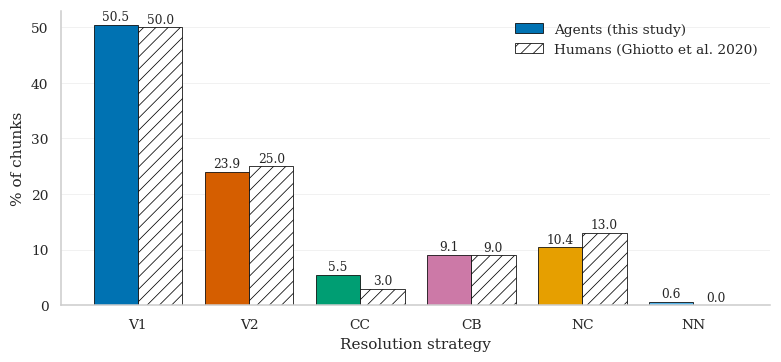

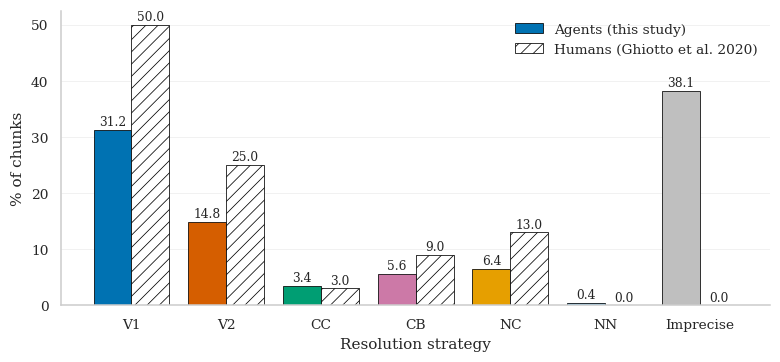

In [4]:
GHIOTTO_HUMAN = {
    "V1": 50,
    "V2": 25,
    "CC": 3,
    "CB":  9,
    "NC": 13,
    "NN":  0,
    "Imprecise": 0.00,   # not reported in Ghiotto; kept as 0 for alignment
}

def _plot_vs_ghiotto(order, agent_dist_row, fname, annotate_imprecise=None):
    agent_pct = (agent_dist_row.reindex(order).fillna(0) * 100)
    human_pct = pd.Series({k: GHIOTTO_HUMAN[k] for k in order})
    x = np.arange(len(order))
    w = 0.4
    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    # Agents: strategy colour fill, no hatch (luminance does the work)
    ax.bar(x - w/2, agent_pct.values, width=w,
           color=[STRATEGY_PALETTE[s] for s in order],
           edgecolor="black", linewidth=0.5, label="Agents (this study)")
    # Ghiotto reference: white fill + diagonal hatch (B&W-safe)
    ax.bar(x + w/2, human_pct.values, width=w,
           color="white", edgecolor="black", hatch="///",
           linewidth=0.5, label="Humans (Ghiotto et al. 2020)")
    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("% of chunks")
    ax.set_xlabel("Resolution strategy")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper right", frameon=False)
    for i, v in enumerate(agent_pct.values):
        ax.text(x[i] - w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    for i, v in enumerate(human_pct.values):
        ax.text(x[i] + w/2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8)
    if annotate_imprecise is not None:
        ax.text(0.99, 0.98,
                f"Imprecise chunks excluded: {annotate_imprecise:.1f}%",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                color="dimgray")
    save_fig(fig, fname)
    plt.show()

if chunks.empty:
    print("No classified chunks yet -- run the pipeline first.")
else:
    # Paper variant: excluding Imprecise
    _plot_vs_ghiotto(
        STRATEGY_ORDER_EXCL,
        global_dist_excl.iloc[0],
        "rq2_global_vs_ghiotto_excl_imprecise",
        # annotate_imprecise=imp_pct_global,
    )
    # Full variant: including Imprecise (for reviewers / appendix)
    _plot_vs_ghiotto(
        STRATEGY_ORDER,
        global_dist_incl.iloc[0],
        "rq2_global_vs_ghiotto_incl_imprecise",
    )

## 4. Figure 2 — Strategy distribution by agent (vertical stacked bars)

Each column is an agent; segment colours + hatches are the canonical
strategies. The paper figure excludes `Imprecise`; the per-agent
Imprecise share is printed below as a small table so it can still be
discussed in the text.

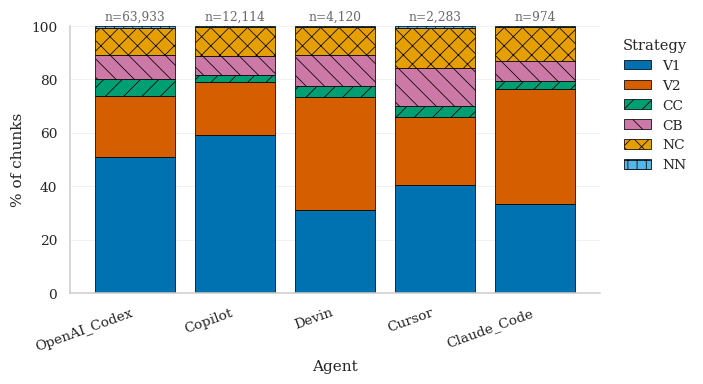

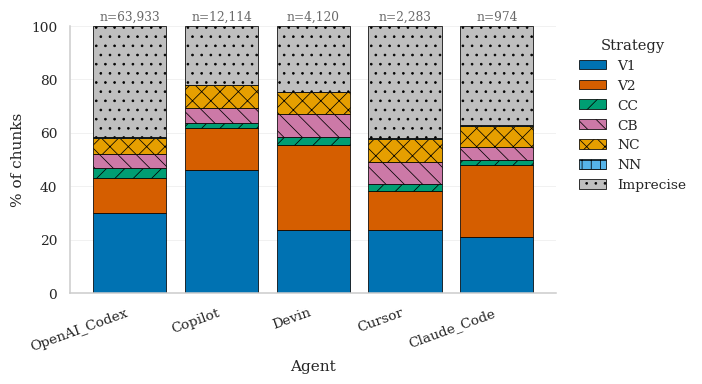

Chunks per agent:
agent
OpenAI_Codex    77598
Copilot         12142
Devin            4903
Cursor           2651
Claude_Code      1028

Imprecise share per agent (%):
agent
Cursor          41.83
OpenAI_Codex    41.43
Claude_Code     37.16
Devin           24.56
Copilot         21.98


In [5]:
if not chunks.empty and "agent" in chunks.columns:
    # Paper view (excluding Imprecise)
    by_agent_excl = strategy_frame_for_plot(chunks, "agent", exclude_imprecise=True)
    ax = plot_strategy_stacked(by_agent_excl, STRATEGY_ORDER_EXCL,
                               orientation="vertical")
    ax.set_xlabel("Agent")
    save_fig(ax.figure, "rq2_by_agent_excl_imprecise")
    plt.show()

    # Full view (including Imprecise)
    by_agent_incl = strategy_frame_for_plot(chunks, "agent", exclude_imprecise=False)
    ax = plot_strategy_stacked(by_agent_incl, STRATEGY_ORDER,
                               orientation="vertical")
    ax.set_xlabel("Agent")
    save_fig(ax.figure, "rq2_by_agent_incl_imprecise")
    plt.show()

    print("Chunks per agent:")
    print(chunks["agent"].value_counts().to_string())
    print("\nImprecise share per agent (%):")
    print((imprecise_share(chunks, group_col="agent") * 100).round(2).sort_values(ascending=False).to_string())

## 5. Figure 3 — Strategy distribution by language (top-N)

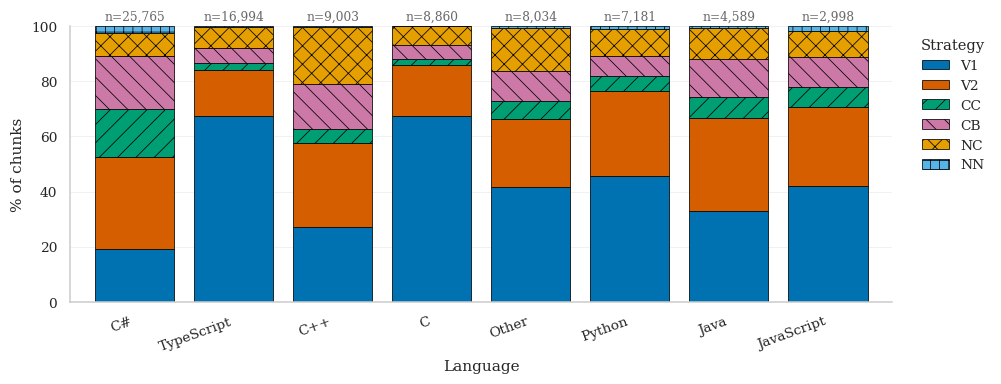

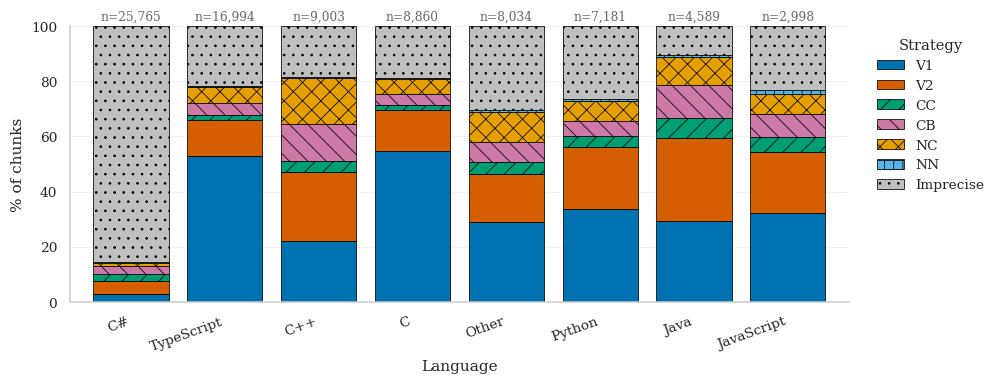


Imprecise share per language (%):
language_top
C#            85.45
Other         30.52
Python        26.47
JavaScript    23.25
TypeScript    21.80
Unknown       19.51
C             18.96
C++           18.49
Java          10.63


In [6]:
if not chunks.empty and "language_top" in chunks.columns:
    by_lang_excl = strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=True)
    ax = plot_strategy_stacked(by_lang_excl, STRATEGY_ORDER_EXCL,
                               orientation="vertical")
    ax.set_xlabel("Language")
    save_fig(ax.figure, "rq2_by_language_excl_imprecise")
    plt.show()

    by_lang_incl = strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=False)
    ax = plot_strategy_stacked(by_lang_incl, STRATEGY_ORDER,
                               orientation="vertical")
    ax.set_xlabel("Language")
    save_fig(ax.figure, "rq2_by_language_incl_imprecise")
    plt.show()

    print("\nImprecise share per language (%):")
    print((imprecise_share(chunks, group_col="language_top") * 100).round(2).sort_values(ascending=False).to_string())

## 6. Figure 4 — Strategy distribution by PR task type

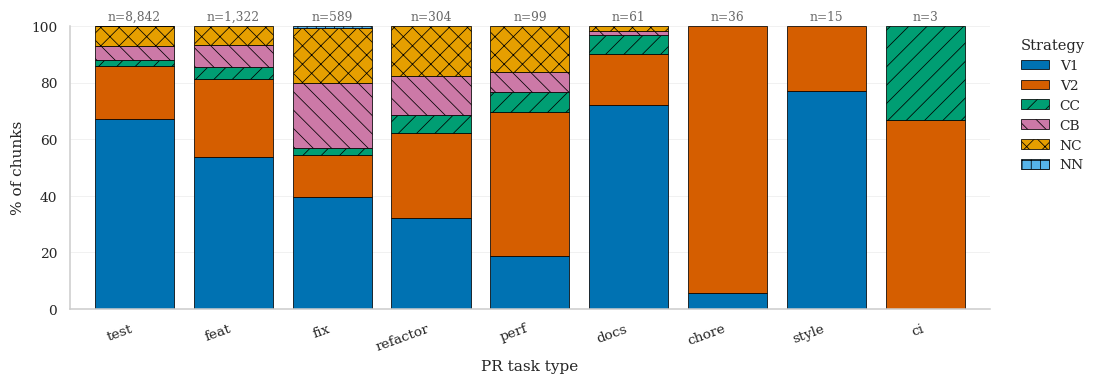

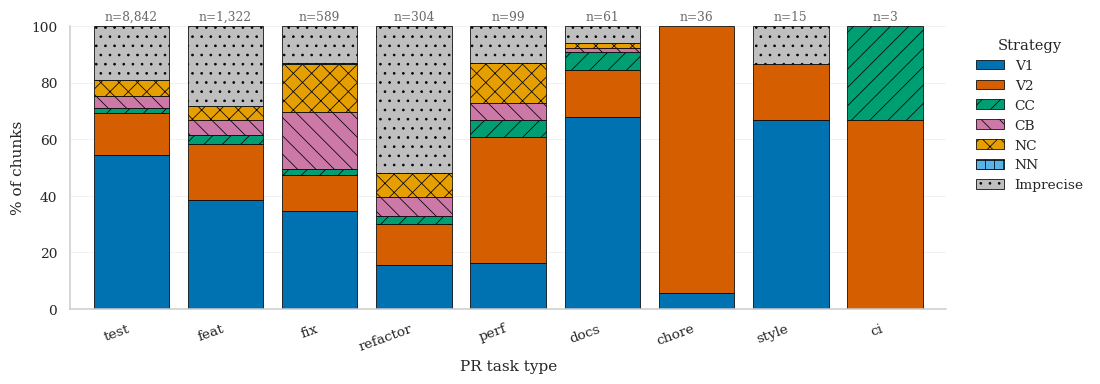


Imprecise share per PR task type (%):
pr_task_type
refactor    51.97
feat        28.29
test        19.12
style       13.33
perf        13.13
fix         13.07
docs         6.15
chore        0.00
ci           0.00


In [7]:
if not chunks.empty and "pr_task_type" in chunks.columns:
    subset = chunks.dropna(subset=["pr_task_type"]).copy()
    if subset.empty:
        print("pr_task_type is only populated under --pop-only.")
    else:
        by_task_excl = strategy_frame_for_plot(subset, "pr_task_type", exclude_imprecise=True)
        ax = plot_strategy_stacked(by_task_excl, STRATEGY_ORDER_EXCL,
                                   orientation="vertical")
        ax.set_xlabel("PR task type")
        save_fig(ax.figure, "rq2_by_task_type_excl_imprecise")
        plt.show()

        by_task_incl = strategy_frame_for_plot(subset, "pr_task_type", exclude_imprecise=False)
        ax = plot_strategy_stacked(by_task_incl, STRATEGY_ORDER,
                                   orientation="vertical")
        ax.set_xlabel("PR task type")
        save_fig(ax.figure, "rq2_by_task_type_incl_imprecise")
        plt.show()

        print("\nImprecise share per PR task type (%):")
        print((imprecise_share(subset, group_col="pr_task_type") * 100).round(2).sort_values(ascending=False).to_string())

## 7. Figure 5 — Ghiotto-Figure-16-style horizontal breakdown

Ghiotto et al.\ (TSE 2020) report the strategy distribution in a
**horizontal 100%-stacked** layout, one bar per slice, with the
strategy segments ordered consistently and annotated with the sample
size. This view is better than grouped vertical bars when the slices
have long labels (languages, PR task types) and when the reader needs
to scan shares across rows at a glance.

We replicate that layout for the four cross-cutting axes of this
study — agent, resolver, language (top-N), and PR task type — in a
single composite figure. The paper variant excludes `Imprecise`; the
audit variant (with `Imprecise` kept as its own segment) is saved
next to it. The panels share the same legend, colour map, and hatch
map, so the figure reads as a single coordinated view.

/home/heleno/agentic-conflicts/analysis/common.py:712: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


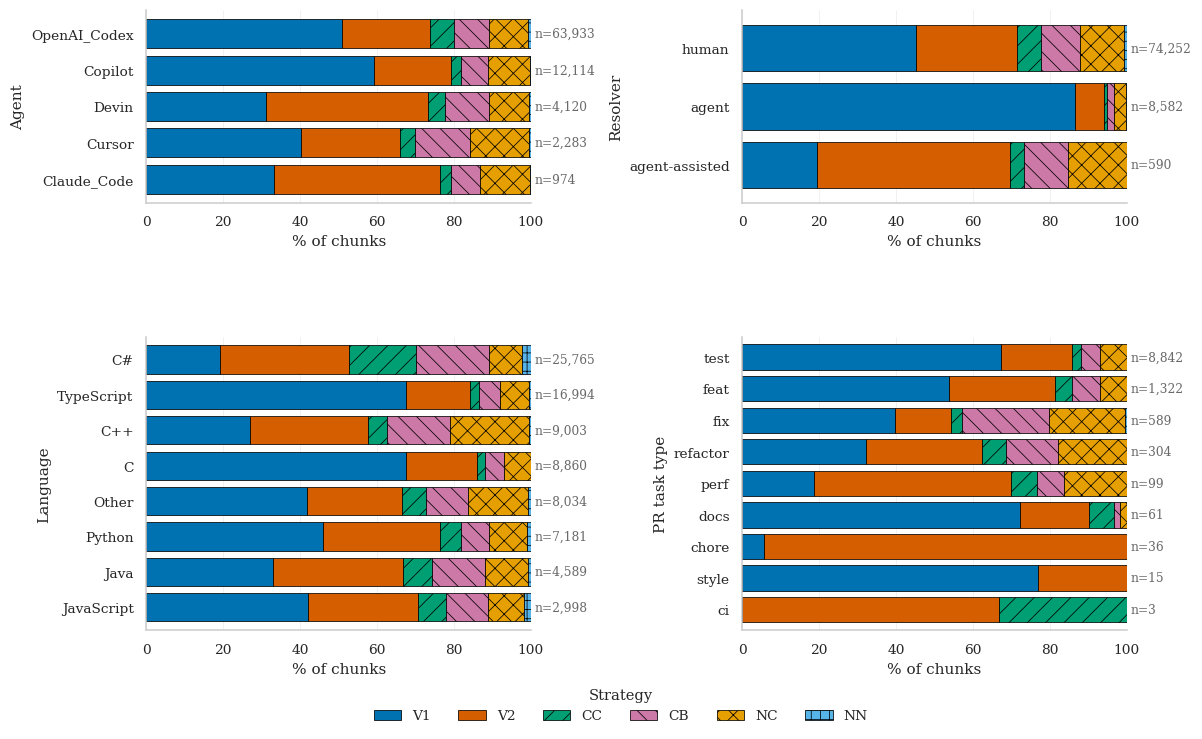

/home/heleno/agentic-conflicts/analysis/common.py:712: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


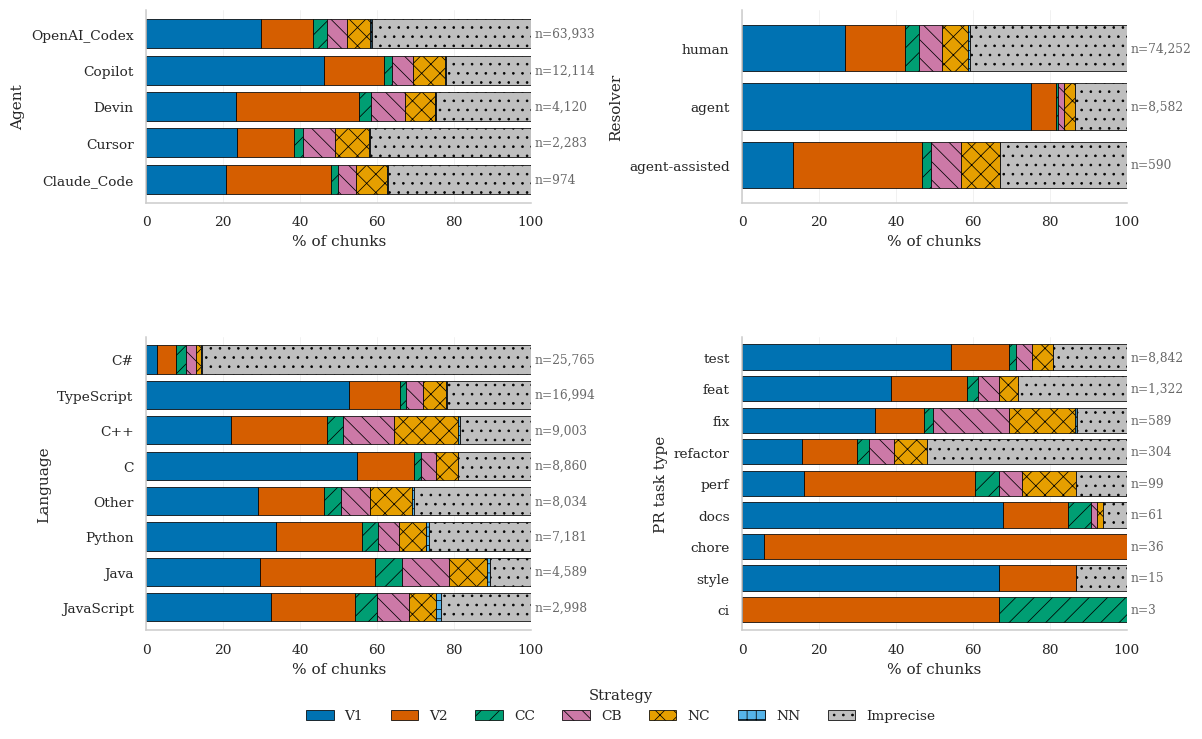

In [8]:
def _composite_fig16(exclude_imprecise: bool):
    """Four-panel horizontal stacked-bar composite (Ghiotto Fig. 16 style).

    Panels:
      (a) by agent              (top-left)
      (b) by resolver type      (top-right)
      (c) by language (top-N)   (bottom-left)
      (d) by PR task type       (bottom-right, AIDev-pop only)
    """
    order = STRATEGY_ORDER_EXCL if exclude_imprecise else STRATEGY_ORDER

    # Build each frame -- drop any axis whose column is absent from the
    # chunk frame (``resolver_type`` and ``pr_task_type`` may be missing
    # under certain pipeline tiers).
    panels = []
    if "agent" in chunks.columns:
        panels.append(("Agent",
                       strategy_frame_for_plot(chunks, "agent",
                                               exclude_imprecise=exclude_imprecise)))
    if "resolver_type" in chunks.columns:
        sub = chunks[chunks["resolver_type"].isin(["agent", "human", "agent-assisted"])]
        if not sub.empty:
            panels.append(("Resolver",
                           strategy_frame_for_plot(sub, "resolver_type",
                                                   exclude_imprecise=exclude_imprecise)))
    if "language_top" in chunks.columns:
        panels.append(("Language",
                       strategy_frame_for_plot(chunks, "language_top",
                                               exclude_imprecise=exclude_imprecise)))
    if "pr_task_type" in chunks.columns:
        task_sub = chunks.dropna(subset=["pr_task_type"])
        if not task_sub.empty:
            panels.append(("PR task type",
                           strategy_frame_for_plot(task_sub, "pr_task_type",
                                                   exclude_imprecise=exclude_imprecise)))

    n = len(panels)
    if n == 0:
        print("No stratifications available; skipping composite figure.")
        return

    # Two-column grid that holds up to 4 panels. Row heights grow with
    # the number of rows in each frame so no label overlaps.
    ncols = 2 if n >= 2 else 1
    nrows = (n + ncols - 1) // ncols
    heights = []
    for i in range(nrows):
        row_panels = panels[i * ncols : (i + 1) * ncols]
        max_rows = max(len(df) for _, df in row_panels)
        heights.append(max(2.2, 0.38 * max_rows + 1.0))
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(11.5, sum(heights)),
        gridspec_kw={"height_ratios": heights, "wspace": 0.55, "hspace": 0.55},
        squeeze=False,
    )

    for idx, (label, df) in enumerate(panels):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        plot_strategy_stacked(
            df, order=order, orientation="horizontal", ax=ax,
            annotate_n=True, legend=False,
        )
        ax.set_xlabel("% of chunks")
        ax.set_ylabel(label, fontsize=10)

    # Hide any unused subplot cells so the figure stays clean.
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_visible(False)

    # Single shared legend at the bottom of the figure.
    handles = [
        plt.Rectangle((0, 0), 1, 1,
                      facecolor=STRATEGY_PALETTE[s],
                      hatch=STRATEGY_HATCH.get(s, ""),
                      edgecolor="black", linewidth=0.5)
        for s in order
    ]
    fig.legend(
        handles, order,
        title="Strategy",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(order), frameon=False,
    )

    suffix = "excl_imprecise" if exclude_imprecise else "incl_imprecise"
    save_fig(fig, f"rq2_fig16_composite_{suffix}")
    plt.show()


if not chunks.empty:
    # Paper variant
    _composite_fig16(exclude_imprecise=True)
    # Audit variant
    _composite_fig16(exclude_imprecise=False)

### 7a. Single-axis horizontal breakdowns

Individual Ghiotto-Fig.-16-style figures per stratum, saved as
stand-alone PDFs so the paper can include them independently of the
composite. Same palette, same hatches, same ordering as the
composite.

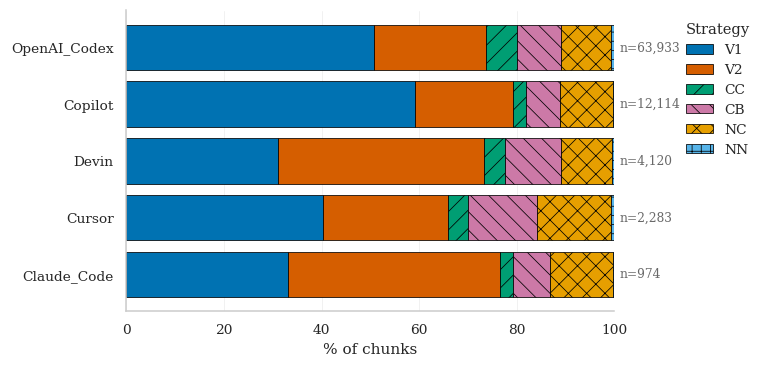

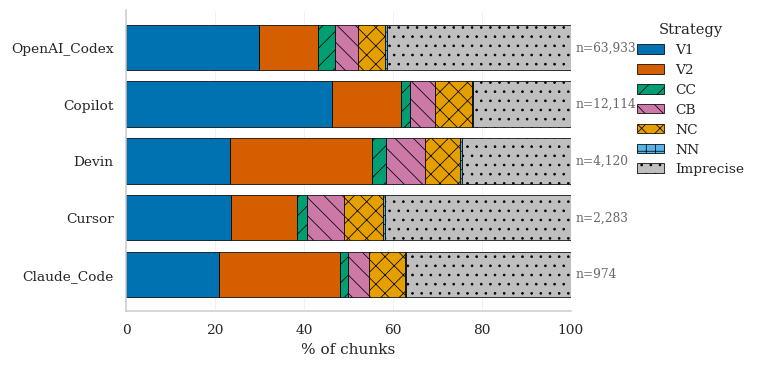

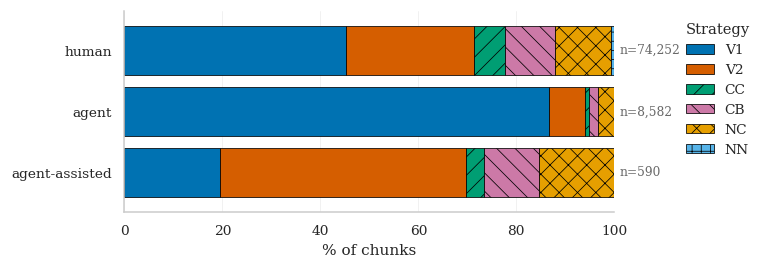

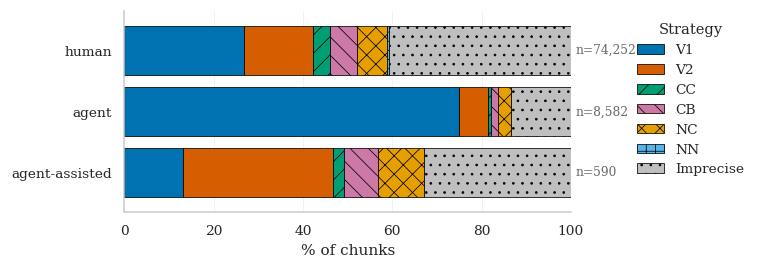

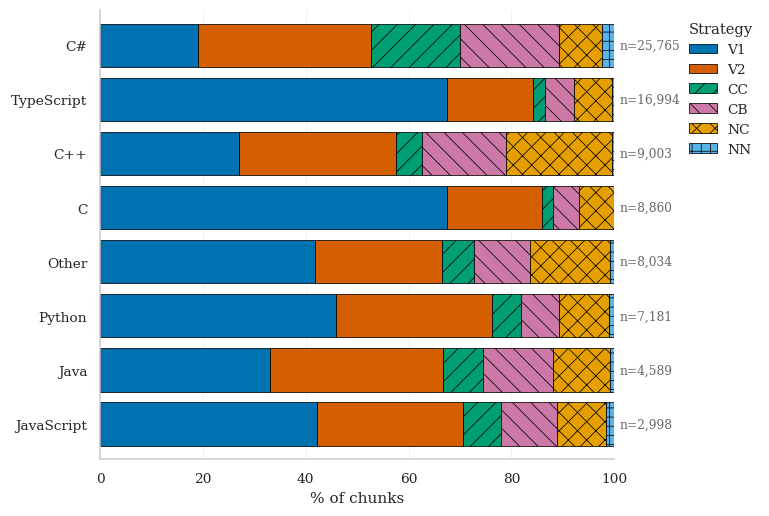

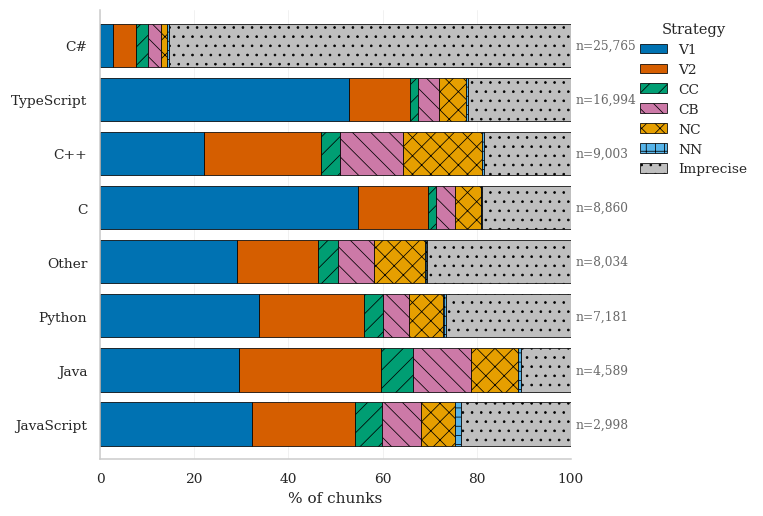

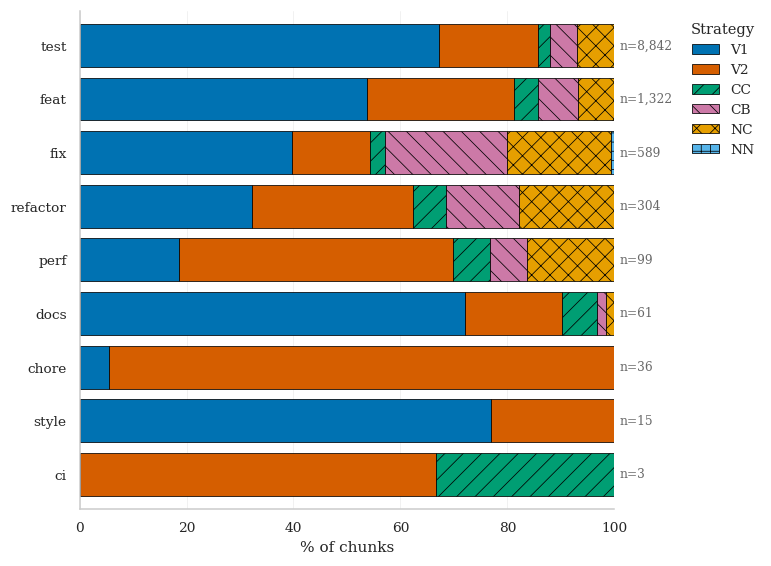

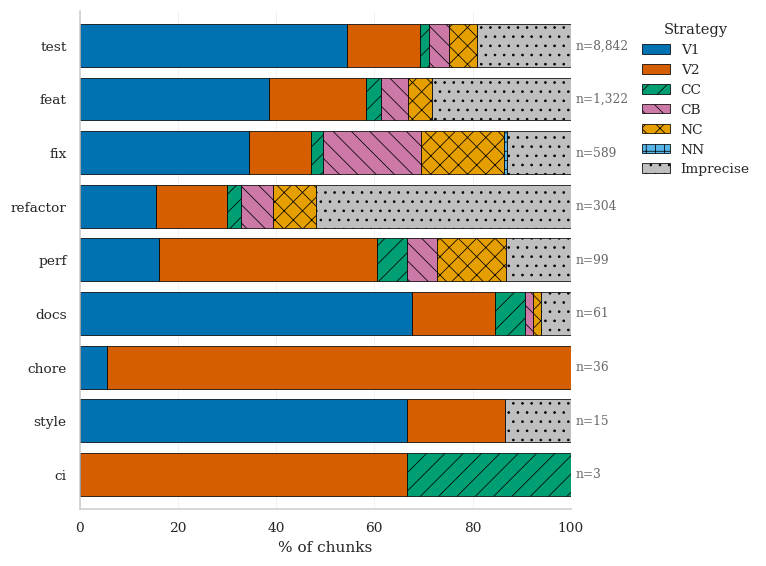

In [9]:
def _single_fig16(df, fname, exclude_imprecise=True):
    order = STRATEGY_ORDER_EXCL if exclude_imprecise else STRATEGY_ORDER
    ax = plot_strategy_stacked(df, order=order, orientation="horizontal",
                               annotate_n=True, legend=True)
    save_fig(ax.figure, fname)
    plt.show()


if not chunks.empty:
    if "agent" in chunks.columns:
        _single_fig16(
            strategy_frame_for_plot(chunks, "agent", exclude_imprecise=True),
            "rq2_fig16_by_agent_excl_imprecise", exclude_imprecise=True,
        )
        _single_fig16(
            strategy_frame_for_plot(chunks, "agent", exclude_imprecise=False),
            "rq2_fig16_by_agent_incl_imprecise", exclude_imprecise=False,
        )

    if "resolver_type" in chunks.columns:
        sub = chunks[chunks["resolver_type"].isin(["agent", "human", "agent-assisted"])]
        if not sub.empty:
            _single_fig16(
                strategy_frame_for_plot(sub, "resolver_type", exclude_imprecise=True),
                "rq2_fig16_by_resolver_excl_imprecise", exclude_imprecise=True,
            )
            _single_fig16(
                strategy_frame_for_plot(sub, "resolver_type", exclude_imprecise=False),
                "rq2_fig16_by_resolver_incl_imprecise", exclude_imprecise=False,
            )

    if "language_top" in chunks.columns:
        _single_fig16(
            strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=True),
            "rq2_fig16_by_language_excl_imprecise", exclude_imprecise=True,
        )
        _single_fig16(
            strategy_frame_for_plot(chunks, "language_top", exclude_imprecise=False),
            "rq2_fig16_by_language_incl_imprecise", exclude_imprecise=False,
        )

    if "pr_task_type" in chunks.columns:
        task_sub = chunks.dropna(subset=["pr_task_type"])
        if not task_sub.empty:
            _single_fig16(
                strategy_frame_for_plot(task_sub, "pr_task_type", exclude_imprecise=True),
                "rq2_fig16_by_task_type_excl_imprecise", exclude_imprecise=True,
            )
            _single_fig16(
                strategy_frame_for_plot(task_sub, "pr_task_type", exclude_imprecise=False),
                "rq2_fig16_by_task_type_incl_imprecise", exclude_imprecise=False,
            )

## 8. Per-stratum numerical tables

In [10]:
if not chunks.empty:
    for axis in ("agent", "language_top", "pr_task_type", "resolver_type"):
        if axis not in chunks.columns:
            continue
        # Paper view
        tbl_excl = strategy_distribution(chunks, group_col=axis, exclude_imprecise=True) * 100
        tbl_excl["n_classifiable"] = chunks[chunks["strategy"] != "Imprecise"].groupby(axis).size()
        tbl_excl["imprecise_pct"] = (imprecise_share(chunks, group_col=axis) * 100).round(2)
        tbl_excl["n_total"] = chunks.groupby(axis).size()
        tbl_excl = tbl_excl.sort_values("n_total", ascending=False).round(2)
        print(f"\n=== Strategy % by {axis} (Imprecise excluded) ===")
        print(tbl_excl.to_string())

        # Full view
        tbl_incl = strategy_distribution(chunks, group_col=axis) * 100
        tbl_incl["n"] = chunks.groupby(axis).size()
        tbl_incl = tbl_incl.sort_values("n", ascending=False).round(2)
        print(f"\n=== Strategy % by {axis} (Imprecise included) ===")
        print(tbl_incl.to_string())


=== Strategy % by agent (Imprecise excluded) ===
strategy         V1     V2    CC     CB     NC    NN  n_classifiable  imprecise_pct  n_total
agent                                                                                       
OpenAI_Codex  50.81  22.95  6.30   9.11  10.13  0.71           45453          41.43    77598
Copilot       59.22  19.96  2.62   7.08  10.81  0.31            9473          21.98    12142
Devin         31.04  42.25  4.24  11.57  10.46  0.43            3699          24.56     4903
Cursor        40.34  25.62  4.02  14.20  15.24  0.58            1542          41.83     2651
Claude_Code   33.13  43.34  2.79   7.59  12.85  0.31             646          37.16     1028

=== Strategy % by agent (Imprecise included) ===
strategy         V1     V2    CC    CB    NC    NN  Imprecise      n
agent                                                               
OpenAI_Codex  29.76  13.44  3.69  5.34  5.93  0.41      41.43  77598
Copilot       46.20  15.57  2.04  5.53  8.

---
### Outputs summary

Figures saved to `analysis/figures/` (two variants each):

| File stem                                          | Paper role |
|----------------------------------------------------|------------|
| `rq2_global_vs_ghiotto_excl_imprecise`             | **Headline figure (paper)** — agents vs. humans, Imprecise excluded |
| `rq2_global_vs_ghiotto_incl_imprecise`             | Audit variant |
| `rq2_by_agent_excl_imprecise`                      | Paper — vertical stacked bars per agent |
| `rq2_by_agent_incl_imprecise`                      | Audit |
| `rq2_by_language_excl_imprecise`                   | Paper — vertical stacked bars per language (top-N) |
| `rq2_by_language_incl_imprecise`                   | Audit |
| `rq2_by_task_type_excl_imprecise`                  | Paper — vertical stacked bars per PR task type |
| `rq2_by_task_type_incl_imprecise`                  | Audit |
| `rq2_fig16_composite_excl_imprecise`               | **Paper — Ghiotto-Fig.-16-style composite**, 4 panels |
| `rq2_fig16_composite_incl_imprecise`               | Audit composite |
| `rq2_fig16_by_{agent,resolver,language,task_type}_excl_imprecise` | Stand-alone single-axis horizontal breakdowns (Ghiotto Fig. 16 style) |
| `rq2_fig16_by_{agent,resolver,language,task_type}_incl_imprecise` | Audit stand-alones |

The paper reports the `excl_imprecise` view and the Imprecise share
separately (globally and per stratum), so readers can tell how many
chunks were dropped from the classifiable distribution.

All figures share a single colour + hatch map for strategies
(`STRATEGY_PALETTE` + `STRATEGY_HATCH` in `analysis/common.py`) and
intentionally omit titles so the LaTeX caption carries the label.